# Preprocessing Data / Feature Engineering:
## Loading Data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [4]:
df = pd.read_csv('financial_regression.csv')
df.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [5]:
df.shape

(3904, 47)

In [6]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          176 non-null    float64
 14  CPI                 176 non-null    float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

In [7]:
print(df.columns)

Index(['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close',
       'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high',
       'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low',
       'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open',
       'silver high', 'silver low', 'silver close', 'silver volume',
       'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close',
       'oil volume', 'oil high-low', 'platinum open', 'platinum high',
       'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume'],
      dtype='object')


In [8]:
print("Percentage of Missing Values (Before Feature Engineering) :")
(df.isnull().sum()/len(df))*100

Percentage of Missing Values (Before Feature Engineering) :


date                   0.000000
sp500 open             4.738730
sp500 high             4.738730
sp500 low              4.738730
sp500 close            4.738730
sp500 volume           4.738730
sp500 high-low         4.738730
nasdaq open            4.738730
nasdaq high            4.738730
nasdaq low             4.738730
nasdaq close           4.738730
nasdaq volume          4.738730
nasdaq high-low        4.738730
us_rates_%            95.491803
CPI                   95.491803
usd_chf                5.379098
eur_usd                5.379098
GDP                   98.539959
silver open            4.738730
silver high            4.738730
silver low             4.738730
silver close           4.738730
silver volume          4.738730
silver high-low        4.738730
oil open               4.738730
oil high               4.738730
oil low                4.738730
oil close              4.738730
oil volume             4.738730
oil high-low           4.738730
platinum open          4.738730
platinum

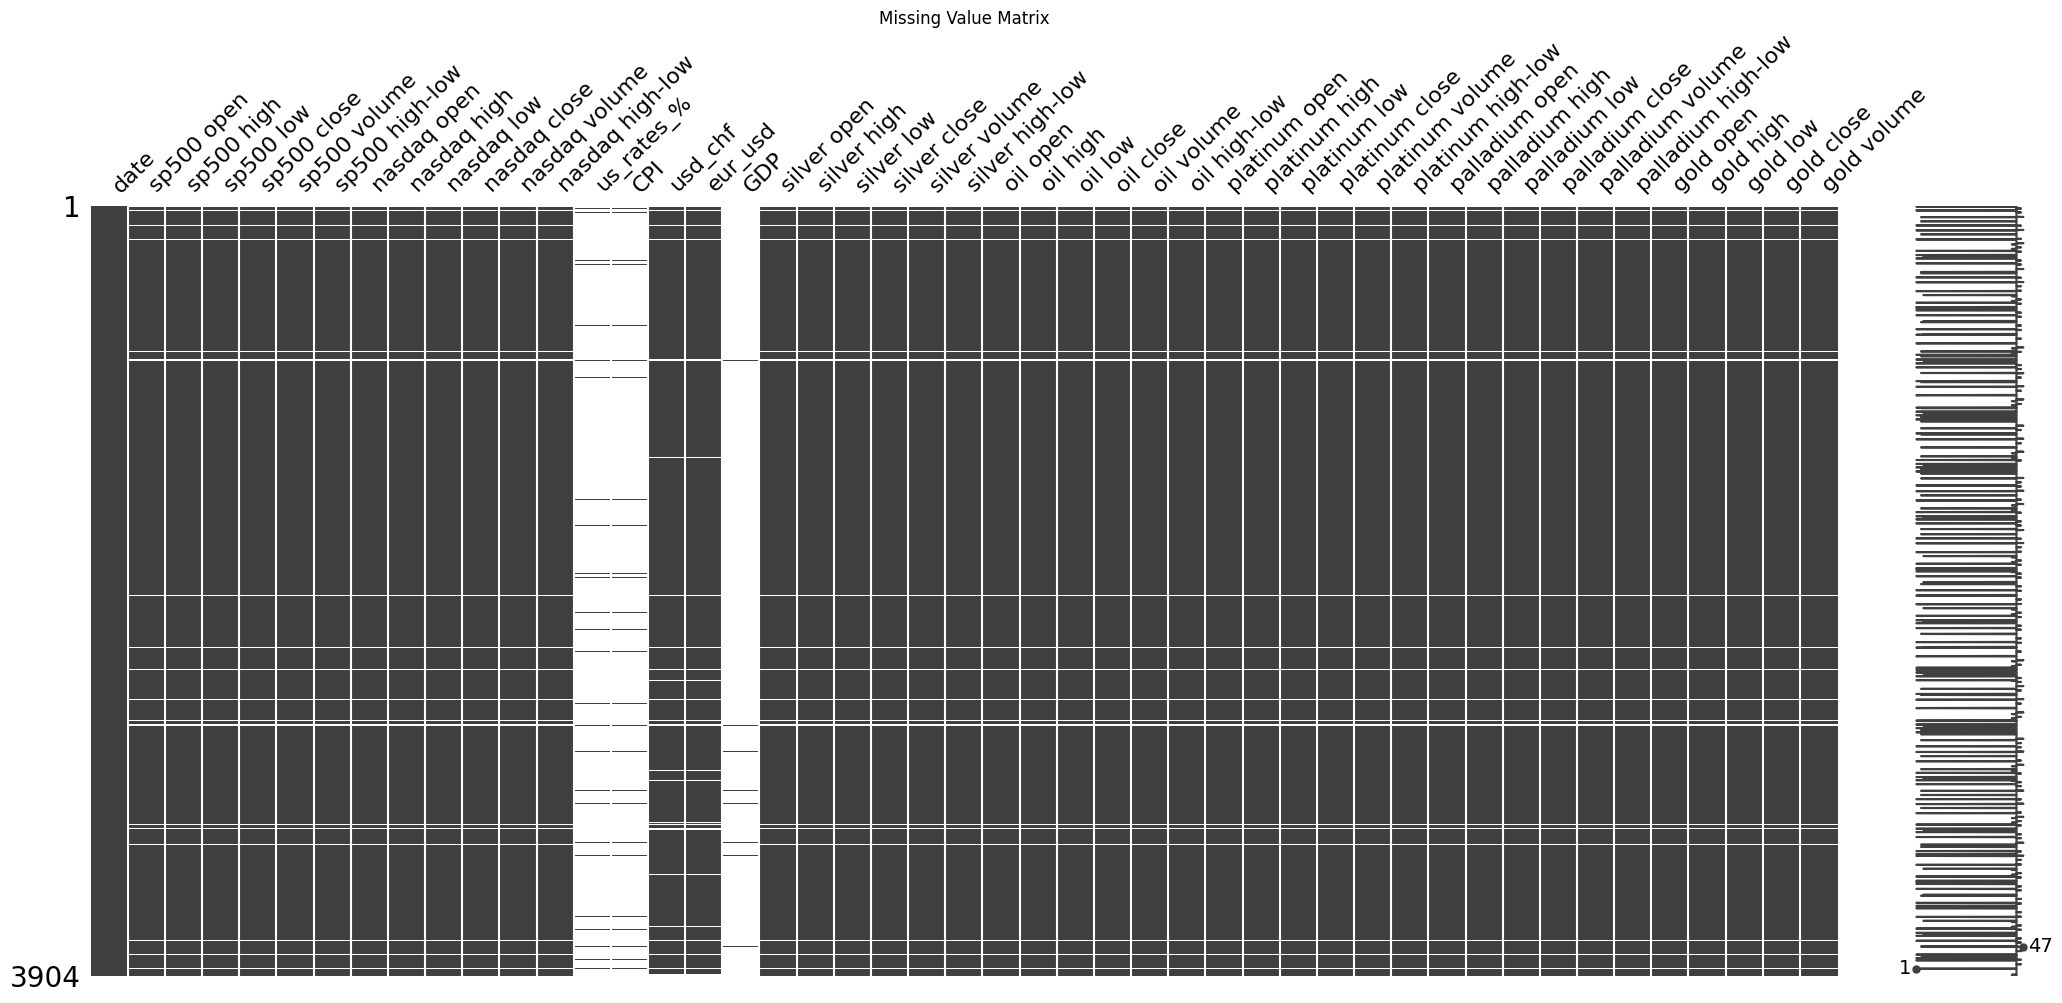

In [9]:
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

In [10]:
# We must standardize the dates in our data in order for our model to understand that markets close on Friday and re-open on Monday.

# Convert to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract calendar components
df["DayOfWeek"] = df["date"].dt.dayofweek  # 0 = Monday, 4 = Friday
df["Month"] = df["date"].dt.month
df["Quarter"] = df["date"].dt.quarter
df["DayOfYear"] = df["date"].dt.dayofyear
df["IsMonthEnd"] = df["date"].dt.is_month_end.astype(int)

In [11]:
# In regards to our linear regression model, we want to predict the future price of gold. In this data set we are split up by the 
# days of the week the stock market is open so we must take this into consideration when we split the model. Here we append the future closing
# price of gold for a given observation as it must serve as our target variable. We also compute the daily return from the difference of the 
# gold open and gold closing price. 

# Create the target: shifted by -1 day (Tomorrow's Close)
df["Target_Next_Close"] = df["gold close"].shift(-1)

# Create lagged features (Yesterday's values)
df["Close_Lag1"] = df["gold close"].shift(1)
df["Open_Lag1"] = df["gold open"].shift(1)

# Daily Return feature (Today's Open to Close spread)
df["Daily_Return"] = (df["gold close"] - df["gold open"]) / df["gold open"]

df[["gold open","gold close","Target_Next_Close","Close_Lag1","Open_Lag1","Daily_Return"]]

,gold open,gold close,Target_Next_Close,Close_Lag1,Open_Lag1,Daily_Return
0,111.51,112.03,110.86,NaN,NaN,0.004663
1,111.35,110.86,NaN,112.03,111.51,-0.004401
2,NaN,NaN,111.52,110.86,111.35,NaN
3,110.95,111.52,108.94,NaN,NaN,0.005137
4,109.97,108.94,107.37,111.52,110.95,-0.009366
...,...,...,...,...,...,...
3899,247.75,248.63,251.27,247.15,247.62,0.003552
3900,250.00,251.27,251.22,248.63,247.75,0.005080
3901,252.74,251.22,253.93,251.27,250.00,-0.006014
3902,253.06,253.93,250.87,251.22,252.74,0.003438


In [12]:
df.shape

(3904, 56)

In [13]:
print("Percentage of Missing Values (After Feature Engineering) :")
(df.isnull().sum()/len(df))*100

Percentage of Missing Values (After Feature Engineering) :


date                   0.000000
sp500 open             4.738730
sp500 high             4.738730
sp500 low              4.738730
sp500 close            4.738730
sp500 volume           4.738730
sp500 high-low         4.738730
nasdaq open            4.738730
nasdaq high            4.738730
nasdaq low             4.738730
nasdaq close           4.738730
nasdaq volume          4.738730
nasdaq high-low        4.738730
us_rates_%            95.491803
CPI                   95.491803
usd_chf                5.379098
eur_usd                5.379098
GDP                   98.539959
silver open            4.738730
silver high            4.738730
silver low             4.738730
silver close           4.738730
silver volume          4.738730
silver high-low        4.738730
oil open               4.738730
oil high               4.738730
oil low                4.738730
oil close              4.738730
oil volume             4.738730
oil high-low           4.738730
platinum open          4.738730
platinum

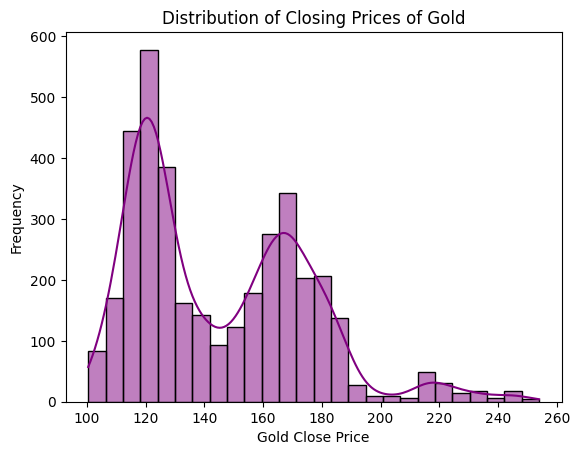

In [14]:
sns.histplot(df["Target_Next_Close"],color = 'purple',kde = True)
plt.title("Distribution of Closing Prices of Gold")
plt.xlabel("Gold Close Price")
plt.ylabel("Frequency")
plt.show()

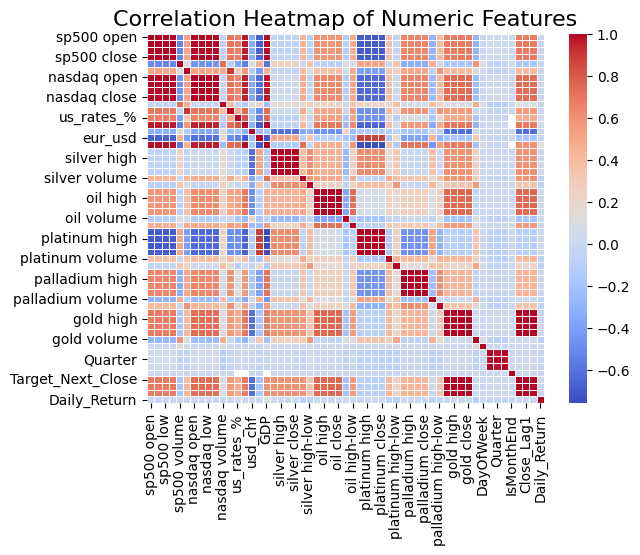

In [15]:
df_numeric = df.select_dtypes(include=[np.number])

sns.heatmap(df_numeric.corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

## Modeling part


In [16]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# FIX: remove market-closed rows BEFORE building target / lags
n_before = len(df)
df = df.dropna(subset=["gold close"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} market-closed rows -> {len(df)} trading days")

# Calendar features
df["DayOfWeek"]  = df["date"].dt.dayofweek
df["Month"]      = df["date"].dt.month
df["Quarter"]    = df["date"].dt.quarter
df["DayOfYear"]  = df["date"].dt.dayofyear
df["IsMonthEnd"] = df["date"].dt.is_month_end.astype(int)

# Target = next trading day's gold close
df["Target_Next_Close"] = df["gold close"].shift(-1)

# Lagged / return features (today's values only; no future information)
df["Close_Lag1"]   = df["gold close"].shift(1)
df["Open_Lag1"]    = df["gold open"].shift(1)
df["Daily_Return"] = (df["gold close"] - df["gold open"]) / df["gold open"]

# The last row has no "tomorrow", so it cannot be used for modeling
model_df = df.dropna(subset=["Target_Next_Close"]).reset_index(drop=True)
print("Modeling dataset:", model_df.shape,
      "|", model_df["date"].min().date(), "to", model_df["date"].max().date())
print("Remaining missing values in market columns:",
      int(model_df.filter(regex="open|high|low|close|volume").isna().sum().sum()))

Dropped 185 market-closed rows -> 3719 trading days
Modeling dataset: (3718, 56) | 2010-01-14 to 2024-10-22
Remaining missing values in market columns: 0


In [17]:
import os, random, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
set_seed()
print("Libraries loaded.")

Libraries loaded.


In [18]:
# Prepare the modeling data
# Preserve chronological order rather than randomly mixing future observations into the training data.
# Make sure observations are in chronological order
df = df.sort_values("date").reset_index(drop=True)

# Remove rows where the target is unavailable
model_df = df.dropna(subset=["Target_Next_Close"]).copy()

print("Modeling dataset shape:", model_df.shape)

Modeling dataset shape: (3718, 56)


In [19]:
features = [
    c for c in model_df.columns
    if c.split(" ")[0] in {"sp500","nasdaq","silver","oil","platinum","palladium","gold"}
] + ["DayOfWeek","Month","Quarter","DayOfYear","IsMonthEnd","Daily_Return"]
print(len(features), "features")

# Smaller feature sets for the sequence / state-space models
seq_features = ["gold close","silver close","oil close","sp500 close","nasdaq close","usd_chf"]
TARGET = "Target_Next_Close"

# Rolling windows: 4 years train -> next year test
windows = [{"train_start": y-4, "train_end": y-1, "test_year": y} for y in range(2012, 2024)]
pd.DataFrame(windows)

47 features


,train_start,train_end,test_year
0,2008,2011,2012
1,2009,2012,2013
2,2010,2013,2014
3,2011,2014,2015
4,2012,2015,2016
5,2013,2016,2017
6,2014,2017,2018
7,2015,2018,2019
8,2016,2019,2020
9,2017,2020,2021


In [20]:
def metrics(y_true, y_pred):
    return (mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred))

def get_window(w):
    yr = model_df["date"].dt.year
    tr = model_df[(yr >= w["train_start"]) & (yr <= w["train_end"])].reset_index(drop=True)
    te = model_df[yr == w["test_year"]].reset_index(drop=True)
    return tr, te

In [21]:
def predict_naive(train, test):
    """Persistence baseline: tomorrow's close = today's close."""
    return test["gold close"].fillna(train["gold close"].median()).values

def predict_linear(train, test):
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()),
                     ("m", LinearRegression())])
    pipe.fit(train[features], train[TARGET])
    return pipe.predict(test[features])

RIDGE_GRID = {"m__alpha": np.logspace(-2, 3, 12)}
def predict_ridge(train, test):
    """Ridge with alpha chosen by TimeSeriesSplit CV inside the training window."""
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()),
                     ("m", Ridge())])
    gs = GridSearchCV(pipe, RIDGE_GRID, cv=TimeSeriesSplit(n_splits=5),
                      scoring="neg_mean_squared_error")
    gs.fit(train[features], train[TARGET])
    predict_ridge.last_alpha = gs.best_params_["m__alpha"]
    return gs.predict(test[features])

def predict_xgb(train, test):
    model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         objective="reg:squarederror", random_state=SEED, n_jobs=-1)
    model.fit(train[features], train[TARGET])      # XGBoost handles NaN natively
    return model.predict(test[features])

def predict_sarimax(train, test):
    """One-step-ahead SARIMAX forecasts.
    Parameters are estimated on the training window only; the test observations are then
    appended (refit=False) so each forecast uses all data available up to that day."""
    med = train[seq_features].median()
    Xtr = train[seq_features].fillna(med).reset_index(drop=True)
    Xte = test[seq_features].fillna(med).reset_index(drop=True)
    ytr = train[TARGET].reset_index(drop=True)
    yte = test[TARGET].reset_index(drop=True)
    # appended data must extend the training index
    shift = len(ytr)
    yte.index = Xte.index = pd.RangeIndex(shift, shift + len(yte))

    fit = SARIMAX(ytr, exog=Xtr, order=(1, 1, 1),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    ext = fit.append(yte, exog=Xte, refit=False)
    pred = ext.get_prediction(start=len(ytr), end=len(ytr) + len(yte) - 1).predicted_mean
    return pred.values

In [22]:
SEQ_LEN = 20

def make_sequences(X, y, seq_len):
    """Window i covers rows [i-seq_len+1 .. i] and predicts y[i]  (window ends ON the prediction day)."""
    Xs, ys = [], []
    for i in range(seq_len - 1, len(X)):
        Xs.append(X[i - seq_len + 1: i + 1])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

def predict_lstm(train, test):
    set_seed()
    tf.keras.backend.clear_session()

    imp = SimpleImputer(strategy="median").fit(train[seq_features])
    Xtr = imp.transform(train[seq_features]); Xte = imp.transform(test[seq_features])
    sx = MinMaxScaler().fit(Xtr);  Xtr = sx.transform(Xtr); Xte = sx.transform(Xte)
    sy = MinMaxScaler().fit(train[[TARGET]])
    ytr = sy.transform(train[[TARGET]]).ravel()

    Xs, ys = make_sequences(Xtr, ytr, SEQ_LEN)

    model = Sequential([
        Input(shape=(SEQ_LEN, Xs.shape[2])),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    # validation_split takes the LAST 10% of sequences (chronological, no shuffling of the split)
    early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model.fit(Xs, ys, epochs=40, batch_size=32, validation_split=0.1,
              shuffle=False, verbose=0, callbacks=[early])

    # Test sequences: prepend the last (SEQ_LEN-1) training rows so every test day has a full window
    comb = np.vstack([Xtr[-(SEQ_LEN - 1):], Xte])
    Xt, _ = make_sequences(comb, np.zeros(len(comb)), SEQ_LEN)
    pred = model.predict(Xt, verbose=0)
    return sy.inverse_transform(pred).ravel()

In [23]:
MODELS = {
    "Naive (today's close)": predict_naive,
    "Linear Regression":     predict_linear,
    "Ridge Regression":      predict_ridge,
    "XGBoost":               predict_xgb,
    "SARIMAX":               predict_sarimax,
    "LSTM":                  predict_lstm,
}

rows, preds_store = [], {}
for w in windows:
    train, test = get_window(w)
    y_true = test[TARGET].values
    for name, fn in MODELS.items():
        try:
            p = fn(train, test)
            assert len(p) == len(y_true), f"{name}: {len(p)} preds vs {len(y_true)} targets"
            mae, rmse, r2 = metrics(y_true, p)
            rows.append({"Test Year": w["test_year"], "Model": name, "MAE": mae, "RMSE": rmse, "R²": r2})
            preds_store[(w["test_year"], name)] = (test["date"].values, y_true, p)
        except Exception as e:
            print(f"{name} failed for {w['test_year']}: {e}")
    print(f"done {w['test_year']}  (train {len(train)} days, test {len(test)} days)")

results = pd.DataFrame(rows)
results.pivot(index="Test Year", columns="Model", values="MAE").round(3)

done 2012  (train 496 days, test 250 days)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done 2013  (train 746 days, test 252 days)
done 2014  (train 998 days, test 252 days)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done 2015  (train 1006 days, test 252 days)
done 2016  (train 1006 days, test 252 days)


...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done 2020  (train 1006 days, test 253 days)
done 2021  (train 1007 days, test 252 days)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done 2022  (train 1008 days, test 251 days)
done 2023  (train 1008 days, test 250 days)


Model,LSTM,Linear Regression,Naive (today's close),Ridge Regression,SARIMAX,XGBoost
Test Year,,,,,,
2012,3.739,1.468,1.078,1.771,1.087,1.545
2013,13.757,1.559,1.255,1.781,1.305,1.843
2014,3.292,0.882,0.803,0.896,0.812,1.930
2015,8.747,0.975,0.762,0.974,0.768,4.716
2016,8.995,1.040,0.888,1.056,0.893,1.694
2017,4.054,0.841,0.602,1.096,0.604,0.783
2018,1.760,0.666,0.543,0.637,0.546,0.922
2019,2.065,0.790,0.741,0.782,0.746,6.448
2020,15.629,2.156,1.462,2.203,1.482,25.337


### Per-year results

In [24]:
for metric in ["RMSE", "R²"]:
    print(f"\n=== {metric} by test year ===")
    display(results.pivot(index="Test Year", columns="Model", values=metric).round(3))


=== RMSE by test year ===


Model,LSTM,Linear Regression,Naive (today's close),Ridge Regression,SARIMAX,XGBoost
Test Year,,,,,,
2012,4.581,1.886,1.526,2.154,1.543,2.000
2013,15.768,2.147,1.828,2.381,1.882,2.539
2014,3.921,1.198,1.120,1.209,1.117,2.444
2015,9.795,1.207,0.996,1.206,1.002,6.313
2016,9.858,1.366,1.207,1.381,1.224,2.069
2017,4.443,1.048,0.751,1.342,0.755,1.012
2018,2.300,0.866,0.731,0.843,0.735,1.190
2019,2.690,1.022,0.986,1.014,0.993,8.806
2020,17.257,2.714,2.047,2.742,2.079,28.311



=== R² by test year ===


Model,LSTM,Linear Regression,Naive (today's close),Ridge Regression,SARIMAX,XGBoost
Test Year,,,,,,
2012,0.433,0.904,0.937,0.875,0.936,0.892
2013,-0.224,0.977,0.984,0.972,0.983,0.968
2014,0.381,0.942,0.950,0.941,0.950,0.760
2015,-2.050,0.954,0.968,0.954,0.968,-0.267
2016,-1.099,0.960,0.969,0.959,0.968,0.908
2017,-1.066,0.885,0.941,0.811,0.940,0.893
2018,0.805,0.972,0.980,0.974,0.980,0.948
2019,0.903,0.986,0.987,0.986,0.987,-0.044
2020,-0.752,0.957,0.975,0.956,0.975,-3.715


In [25]:
order = ["Linear Regression", "Ridge Regression", "XGBoost", "SARIMAX", "LSTM", "Naive (today's close)"]
final = (results.groupby("Model")[["MAE", "RMSE", "R²"]].mean()
         .loc[order].reset_index())
final["Windows with R² > 0"] = [int((results[(results.Model == m)]["R²"] > 0).sum()) for m in order]
final.round(4)

,Model,MAE,RMSE,R²,Windows with R² > 0
0,Linear Regression,1.1726,1.5227,0.9422,12
1,Ridge Regression,1.2912,1.6449,0.9233,12
2,XGBoost,4.1577,5.0621,0.3298,9
3,SARIMAX,0.9758,1.3275,0.9560,12
4,LSTM,7.6807,8.5625,-1.0261,4
5,Naive (today's close),0.9644,1.3140,0.9565,12


In [26]:
# Median is more robust to the extreme 2020 window
(results.groupby("Model")[["MAE", "RMSE", "R²"]].median().loc[order].reset_index()
 .rename(columns=lambda c: c if c == "Model" else c + " (median)").round(4))

,Model,MAE (median),RMSE (median),R² (median)
0,Linear Regression,1.0828,1.4356,0.9552
1,Ridge Regression,1.1341,1.4600,0.9548
2,XGBoost,1.6440,2.0944,0.8713
3,SARIMAX,0.9805,1.3322,0.9664
4,LSTM,8.4175,9.2730,-0.5210
5,Naive (today's close),0.9719,1.3255,0.9673


In [27]:
results[results["Test Year"] == 2023].set_index("Model").loc[order, ["MAE","RMSE","R²"]].round(4)

,MAE,RMSE,R²
Model,,,
Linear Regression,1.1719,1.5400,0.9213
Ridge Regression,1.1722,1.5391,0.9213
XGBoost,1.5839,2.1201,0.8508
SARIMAX,1.1358,1.5236,0.9229
LSTM,8.0876,8.7510,-1.5427
Naive (today's close),1.1366,1.5181,0.9235


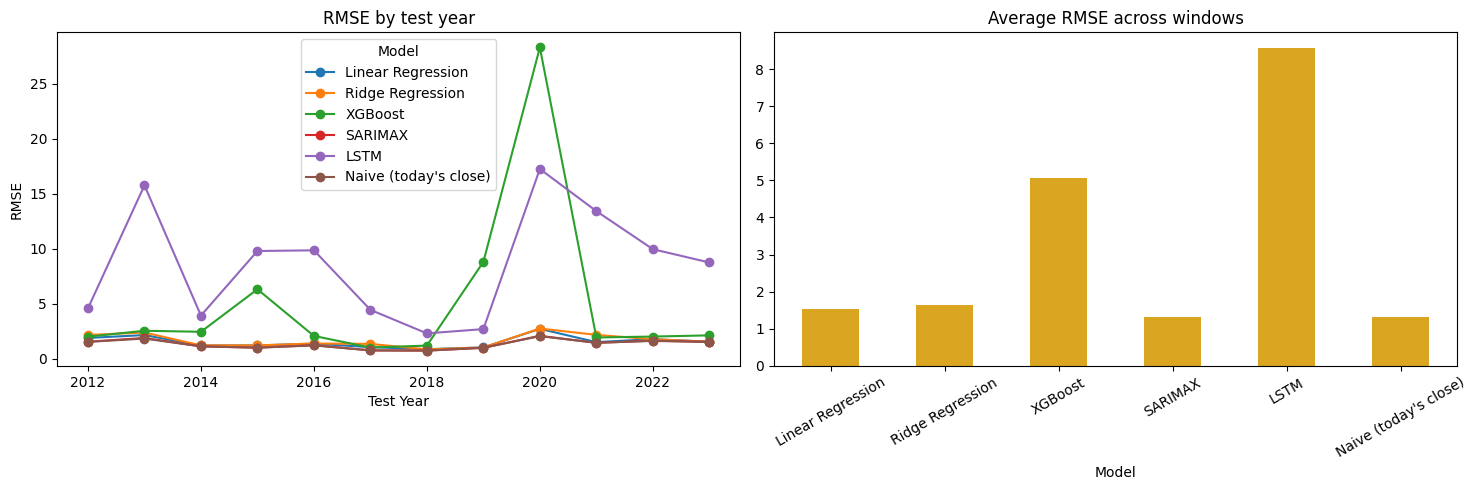

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
piv = results.pivot(index="Test Year", columns="Model", values="RMSE")[order]
piv.plot(marker="o", ax=ax[0]); ax[0].set_title("RMSE by test year"); ax[0].set_ylabel("RMSE")
final.set_index("Model")["RMSE"].plot.bar(ax=ax[1], color="goldenrod")
ax[1].set_title("Average RMSE across windows"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

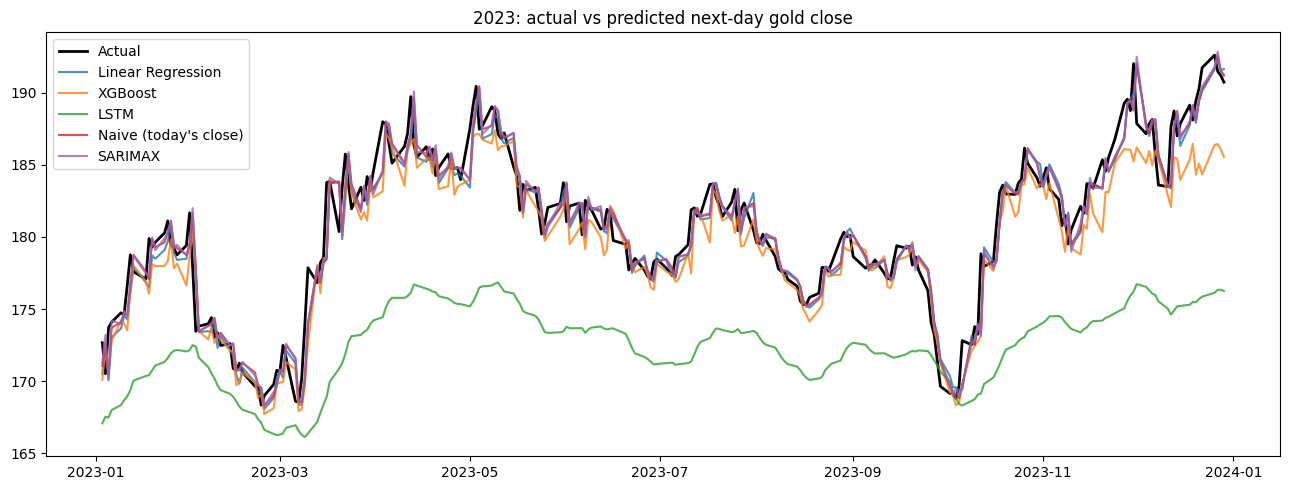

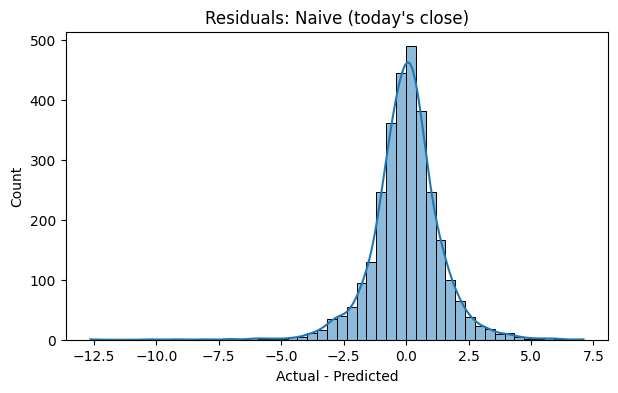

In [37]:
# Actual vs predicted for the 2023 window
fig, ax = plt.subplots(figsize=(13, 5))
d, y, _ = preds_store[(2023, "Linear Regression")]
ax.plot(d, y, label="Actual", color="black", lw=2)
for name in ["Linear Regression", "XGBoost", "LSTM", "Naive (today's close)", "SARIMAX"]:
    ax.plot(preds_store[(2023, name)][0], preds_store[(2023, name)][2], label=name, alpha=0.8)
ax.set_title("2023: actual vs predicted next-day gold close"); ax.legend(); plt.tight_layout(); plt.show()

# Residuals of the best-MAE model across all windows
best = final.sort_values("MAE").iloc[0]["Model"]
res_all = np.concatenate([preds_store[(y, best)][1] - preds_store[(y, best)][2] for y in range(2012, 2024)])
plt.figure(figsize=(7, 4)); sns.histplot(res_all, bins=50, kde=True)
plt.title(f"Residuals: {best}"); plt.xlabel("Actual - Predicted"); plt.show()

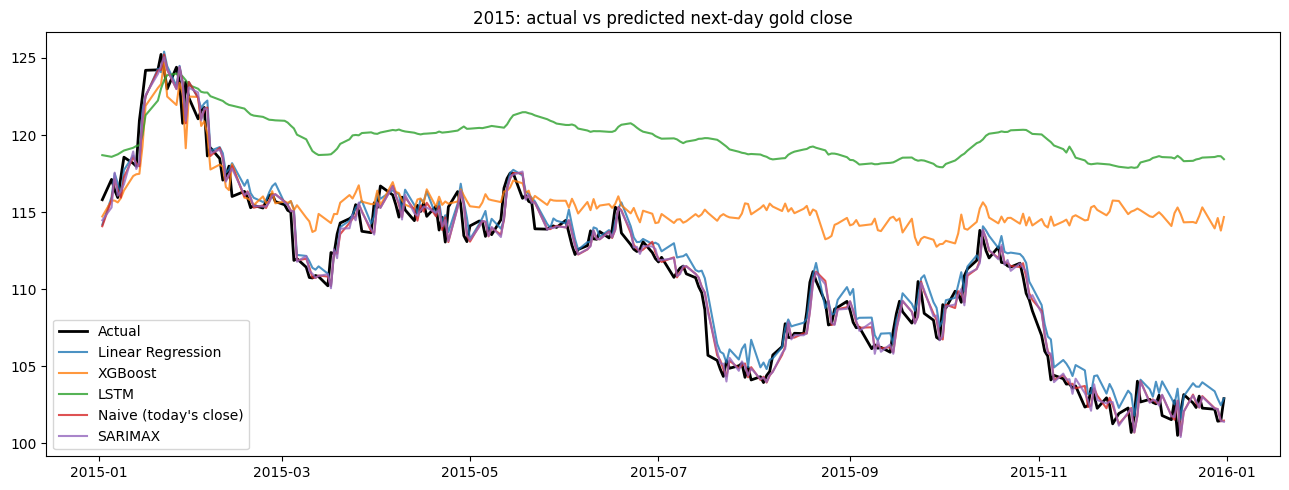

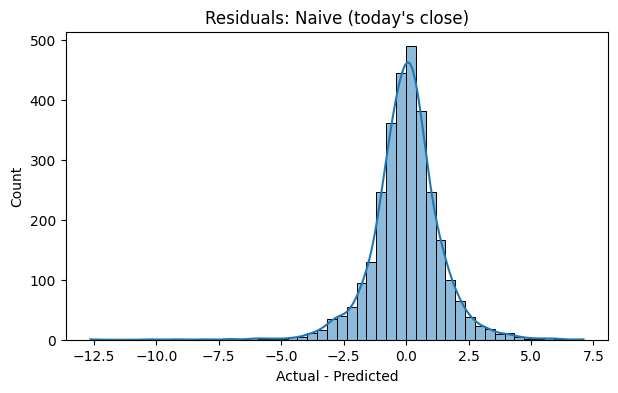

In [38]:
# Actual vs predicted for the 2015 window
fig, ax = plt.subplots(figsize=(13, 5))
d, y, _ = preds_store[(2015, "Linear Regression")]
ax.plot(d, y, label="Actual", color="black", lw=2)
for name in ["Linear Regression", "XGBoost", "LSTM", "Naive (today's close)", "SARIMAX"]:
    ax.plot(preds_store[(2015, name)][0], preds_store[(2015, name)][2], label=name, alpha=0.8)
ax.set_title("2015: actual vs predicted next-day gold close"); ax.legend(); plt.tight_layout(); plt.show()

# Residuals of the best-MAE model across all windows
best = final.sort_values("MAE").iloc[0]["Model"]
res_all = np.concatenate([preds_store[(y, best)][1] - preds_store[(y, best)][2] for y in range(2012, 2024)])
plt.figure(figsize=(7, 4)); sns.histplot(res_all, bins=50, kde=True)
plt.title(f"Residuals: {best}"); plt.xlabel("Actual - Predicted"); plt.show()


In [39]:
print("Best model by average MAE :", final.sort_values("MAE").iloc[0]["Model"])
print("Best model by average RMSE:", final.sort_values("RMSE").iloc[0]["Model"])
print("Best model by average R²  :", final.sort_values("R²", ascending=False).iloc[0]["Model"])

Best model by average MAE : Naive (today's close)
Best model by average RMSE: Naive (today's close)
Best model by average R²  : Naive (today's close)


In [40]:
def with_delta(fn):
    def wrapped(train, test):
        tr = train.copy()
        tr[TARGET] = tr[TARGET] - tr["gold close"]
        return fn(tr, test) + test["gold close"].values
    return wrapped

DELTA_MODELS = {
    "Linear Regression (change)": with_delta(predict_linear),
    "Ridge Regression (change)":  with_delta(predict_ridge),
    "XGBoost (change)":           with_delta(predict_xgb),
    "LSTM (change)":              with_delta(predict_lstm),
}
rows2 = []
for w in windows:
    train, test = get_window(w)
    for name, fn in DELTA_MODELS.items():
        mae, rmse, r2 = metrics(test[TARGET].values, fn(train, test))
        rows2.append({"Test Year": w["test_year"], "Model": name, "MAE": mae, "RMSE": rmse, "R²": r2})
results2 = pd.DataFrame(rows2)
ext = pd.concat([final.set_index("Model").drop(columns="Windows with R² > 0"),
                 results2.groupby("Model")[["MAE","RMSE","R²"]].mean()])
ext.round(4).sort_values("RMSE")

,MAE,RMSE,R²
Model,,,
Naive (today's close),0.9644,1.3140,0.9565
SARIMAX,0.9758,1.3275,0.9560
Ridge Regression (change),1.0008,1.3450,0.9549
XGBoost (change),1.1284,1.4877,0.9423
Linear Regression,1.1726,1.5227,0.9422
Linear Regression (change),1.1726,1.5227,0.9422
Ridge Regression,1.2912,1.6449,0.9233
LSTM (change),1.4681,1.8373,0.8937
XGBoost,4.1577,5.0621,0.3298


In [41]:
for w in windows:
    train, test = get_window(w)
    for name, fn in DELTA_MODELS.items():
        if (w["test_year"], name) in preds_store:
            continue                                   # skip anything already stored
        p = fn(train, test)
        preds_store[(w["test_year"], name)] = (test["date"].values, test[TARGET].values, p)

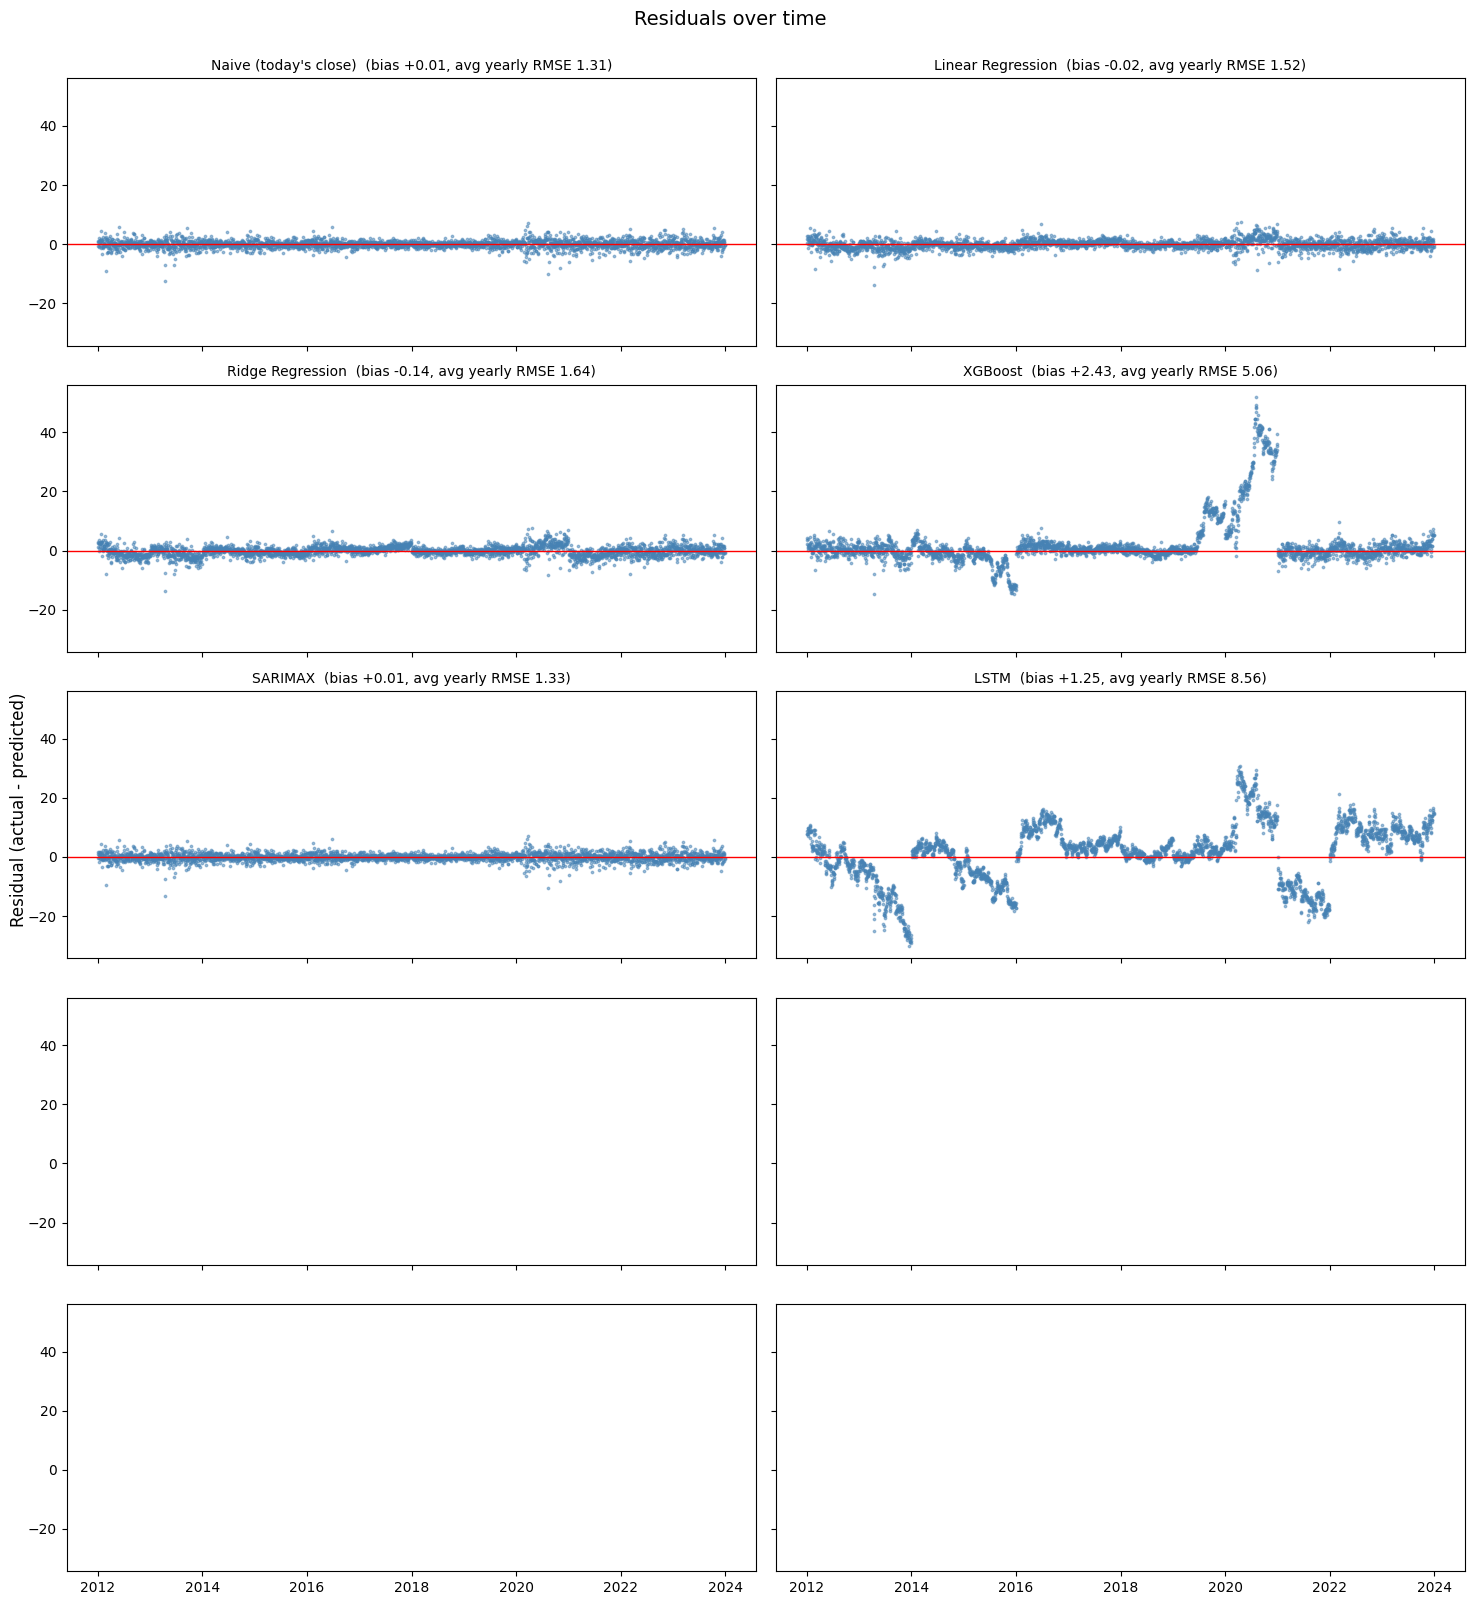

In [47]:
ALL = ["Naive (today's close)", "Linear Regression", "Ridge Regression", "XGBoost", "SARIMAX", "LSTM"]

def pooled(name):
    d, y, p = [], [], []
    for yr in range(2012, 2024):
        a, b, c = preds_store[(yr, name)]
        d.append(a); y.append(b); p.append(c)
    d, y, p = np.concatenate(d), np.concatenate(y), np.concatenate(p)
    return pd.to_datetime(d), y, p, y - p

results_all = pd.concat([results, results2], ignore_index=True)

# (a) Residuals over time, one panel per model (same y-axis for fair comparison)
fig, axes = plt.subplots(5, 2, figsize=(15, 16), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), ALL):
    d, y, p, r = pooled(name)
    ax.scatter(d, r, s=3, alpha=0.5, color="steelblue")
    ax.axhline(0, color="red", lw=1)
    yearly_rmse = results_all.loc[results_all.Model == name, "RMSE"].mean()
    ax.set_title(f"{name}  (bias {r.mean():+.2f}, avg yearly RMSE {yearly_rmse:.2f})", fontsize=10)
fig.supylabel("Residual (actual - predicted)"); fig.suptitle("Residuals over time", y=1.0, fontsize=14)
plt.tight_layout(); plt.show()


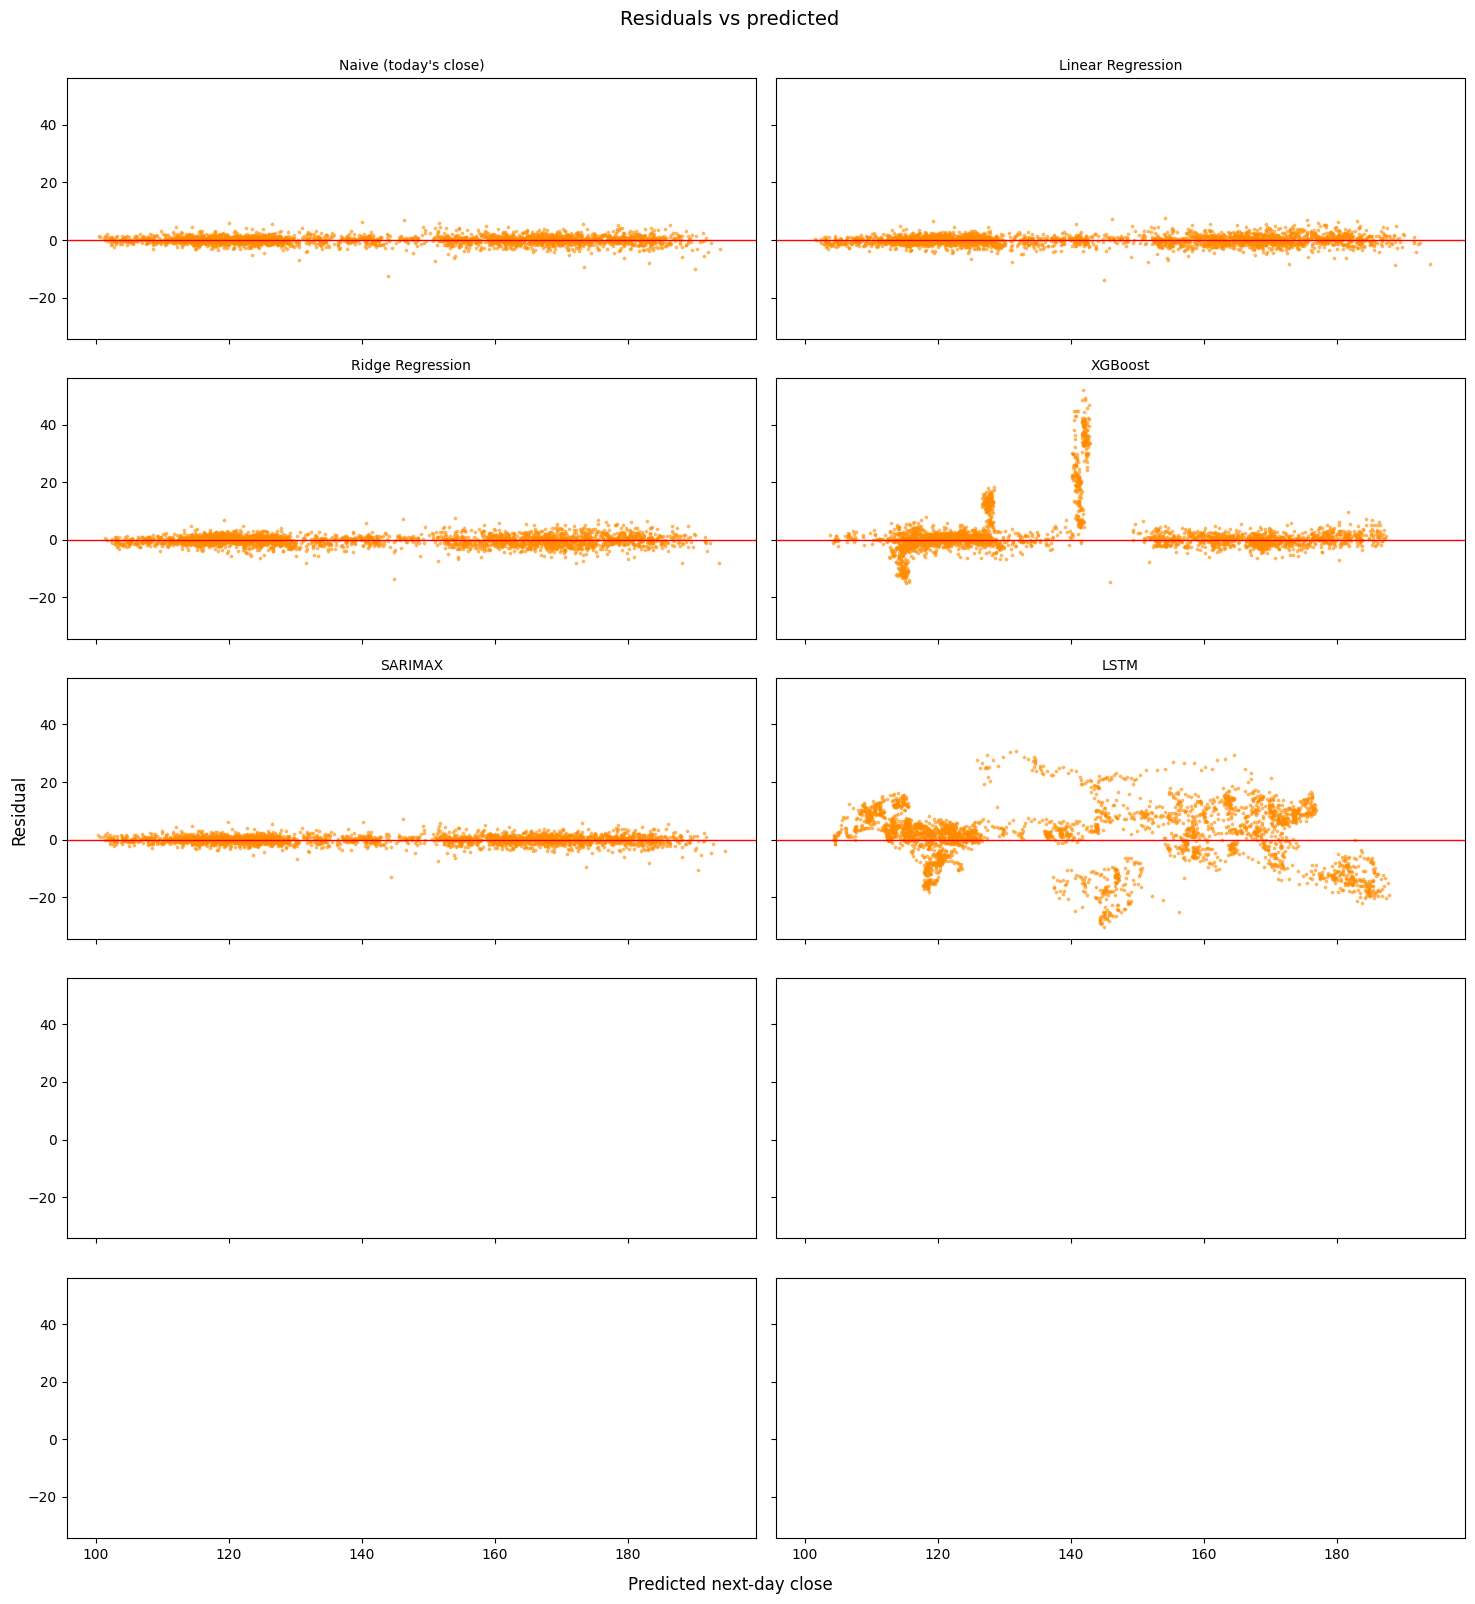

In [48]:
# (b) Residuals vs predicted value
fig, axes = plt.subplots(5, 2, figsize=(15, 16), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), ALL):
    d, y, p, r = pooled(name)
    ax.scatter(p, r, s=3, alpha=0.5, color="darkorange")
    ax.axhline(0, color="red", lw=1); ax.set_title(name, fontsize=10)
fig.supxlabel("Predicted next-day close"); fig.supylabel("Residual")
fig.suptitle("Residuals vs predicted", y=1.0, fontsize=14)
plt.tight_layout(); plt.show()

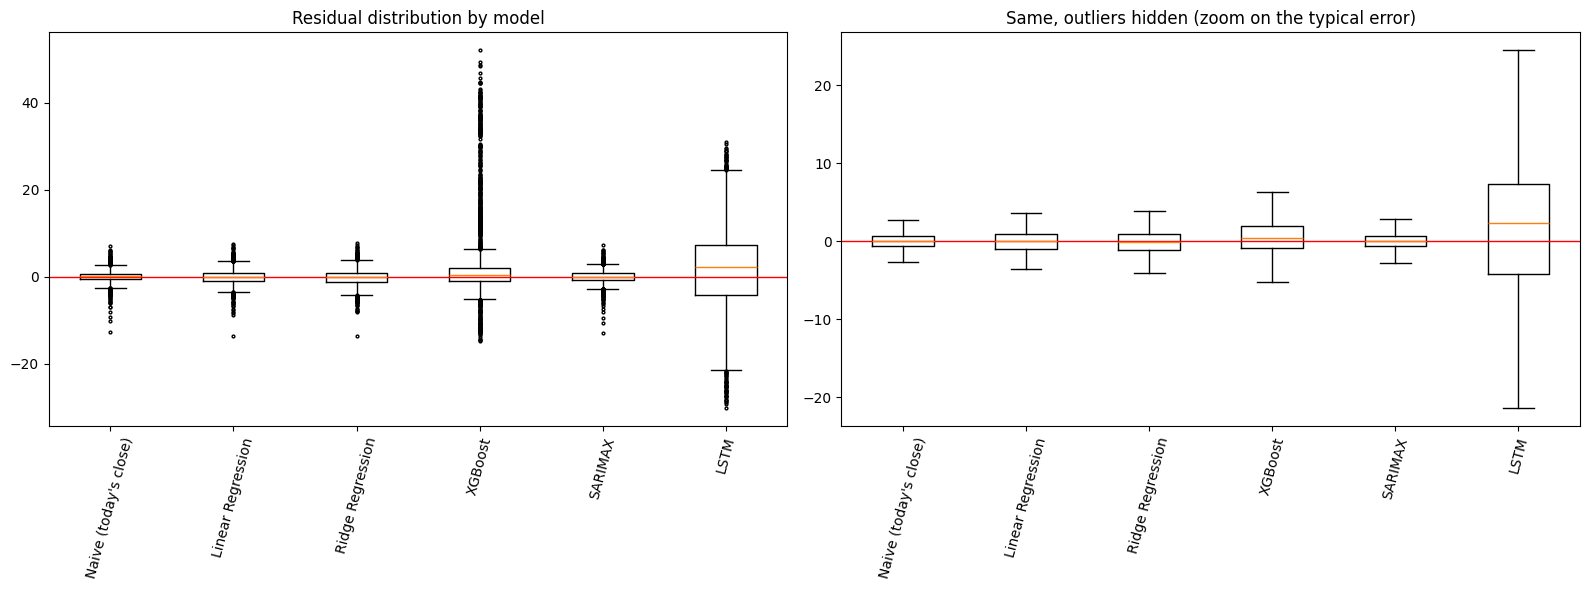

,mean,std,min,50%,max
Naive (today's close),0.01,1.37,-12.64,0.04,7.10
Linear Regression,-0.02,1.61,-13.76,-0.02,7.49
Ridge Regression,-0.14,1.74,-13.57,-0.11,7.68
XGBoost,2.43,8.61,-14.80,0.37,52.02
SARIMAX,0.01,1.39,-13.04,0.02,7.17
LSTM,1.25,9.78,-30.22,2.31,30.88


In [43]:
# (c) Distribution of residuals for every model
data = [pooled(n)[3] for n in ALL]
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].boxplot(data, labels=ALL, showfliers=True, flierprops=dict(markersize=2))
ax[0].axhline(0, color="red", lw=1); ax[0].tick_params(axis="x", rotation=75)
ax[0].set_title("Residual distribution by model")
ax[1].boxplot(data, labels=ALL, showfliers=False)
ax[1].axhline(0, color="red", lw=1); ax[1].tick_params(axis="x", rotation=75)
ax[1].set_title("Same, outliers hidden (zoom on the typical error)")
plt.tight_layout(); plt.show()

pd.DataFrame({n: pd.Series(r).describe() for n, r in zip(ALL, data)}).T[["mean","std","min","50%","max"]].round(2)